# seaborn 学习簿

`seaborn` 是基于 `matplotlib` 的 Python 数据可视化库，专为统计图表设计。它提供了更高级的接口和美观的默认样式，特别适合探索性数据分析和统计可视化。`seaborn` 可以和 `pandas` `polars` 等数据结构紧密集成，处理复杂的数据可视化任务。

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

## 通用方法

### 基本操作

`seaborn` 提供与 `matplotlib` 类似的基本接口，下面的一些基本操作和 `matplotlib` 几乎一样：

- 设置画布大小：`plt.figure(figsize=(width, height))`
  - `figsize`：图形大小，(宽, 高)，单位为英寸

- 设置标题：`plt.title(label)`
  - `label`：图表标题文本

- 显示图形：`plt.show()`

- 创建子图：`plt.subplot(nrows, ncols, index)`
  - `nrows`：子图的行数
  - `ncols`：子图的列数
  - `index`：当前绘制的是第几个子图（从 `1` 开始）

### 主题与风格

#### 全局主题

可以使用 `sns.set_theme()` 方法来设置 `seaborn` 的全局主题风格，可选参数如下：

- 无参数时，使用默认默认主题
- `context`：上下文参数，可选值有 `'paper'`、`'notebook'`、`'talk'`、`'poster'`，默认为 `'notebook'`
- `style`：样式参数，可选值有 `'darkgrid'`、`'whitegrid'`、`'dark'`、`'white'`、`'ticks'`，默认为 `'darkgrid'`
- `palette`：调色盘参数，可选值有 `'deep'`、`'muted'`、`'bright'`、`'pastel'`、`'dark'`、`'colorblind'`，默认为 `'deep'`
- `font`：字体参数，默认为 `'sans-serif'`
- `font_scale`：字体大小参数，默认为 `1`
- `rc`：可以用 `rcParams` 字典重置 `set_theme` 设置的参数

#### 图表样式

可以使用 `sns.set_style()` 方法来设置图表的样式风格，`seaborn` 提供了5种预设样式，可以快速改变图表的主题。

- `'darkgrid'`：黑色背景带有白色网格，数据点和线条颜色较深，对比度高，适合营造深度感和层次感的图表；
- `'whitegrid'`：以白色为背景，灰色网格线辅助，数据点和线条颜色较浅，风格简洁、清新，适合展示简洁明了的数据关系；
- `'dark'`：整个图表以深色系为主，数据点、线条和背景均为深色，文字和其他元素为对比鲜明的亮色，常用于营造高端、大气的视觉效果；
- `'white'`：与 `'dark'` 风格相反，以白色为背景，所有元素基本都呈现为白色或浅色，适合在简洁、明亮的环境中展示图表；
- `'ticks'`：该风格下坐标轴刻度位置有特殊标记，通常是较长的刻度线或特定的标记样式，突出了坐标轴的位置和刻度，使图表更具参考性。

下面是各风格的样例效果：

Available Seaborn style parameters:
{'axes.facecolor': 'white', 'axes.edgecolor': 'black', 'axes.grid': False, 'axes.axisbelow': 'line', 'axes.labelcolor': 'black', 'figure.facecolor': 'white', 'grid.color': '#b0b0b0', 'grid.linestyle': '-', 'text.color': 'black', 'xtick.color': 'black', 'ytick.color': 'black', 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.solid_capstyle': <CapStyle.projecting: 'projecting'>, 'patch.edgecolor': 'black', 'patch.force_edgecolor': False, 'image.cmap': 'viridis', 'font.family': ['sans-serif'], 'font.sans-serif': ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif'], 'xtick.bottom': True, 'xtick.top': False, 'ytick.left': True, 'ytick.right': False, 'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.spines.right': True, 'axes.spines.top': True}
Predefined Seaborn styles:
['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']


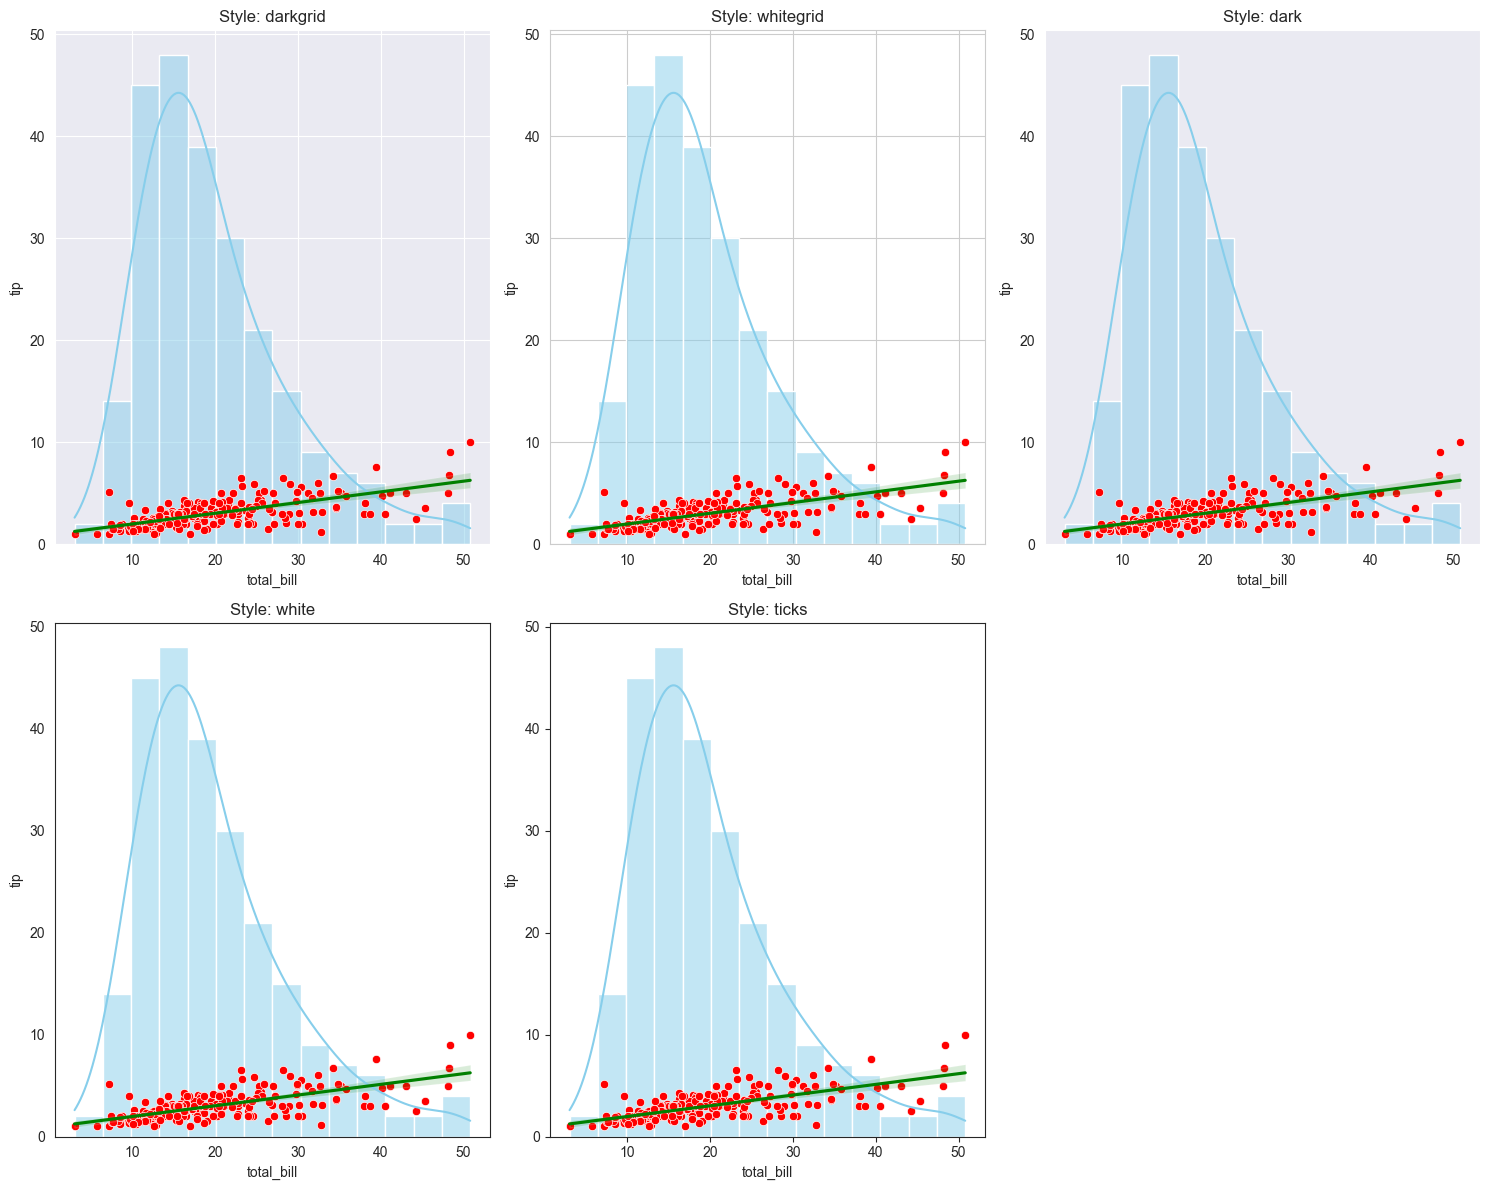

In [2]:
available_styles = sns.axes_style()
print("Available Seaborn style parameters:")
print(available_styles)

predefined_styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
print("Predefined Seaborn styles:")
print(predefined_styles)

data = sns.load_dataset("tips")

plt.figure(figsize=(15, 12))
for i, style in enumerate(predefined_styles, 1):
    sns.set_style(style) # type: ignore
    plt.subplot(2, 3, i)
    
    # histogram + scatter + trend line
    sns.histplot(data=data, x="total_bill", kde=True, color='skyblue')
    sns.scatterplot(data=data, x="total_bill", y="tip", color='red')
    sns.regplot(data=data, x="total_bill", y="tip", scatter=False, color='green')
    
    plt.title(f'Style: {style}')

plt.tight_layout()
plt.show()

#### 上下文样式

`seaborn` 提供了“上下文（*context*）”的概念，上下文是图表展示的环境或场景，针对这些不同的展示场景，可以设置图表元素的大小、缩放、字体等属性。`seaborn` 内置了四种常用的上下文，分别是：

- `'paper'`: 适合用于论文或报告，元素较小，布局紧凑；
- `'notebook'`: 适合在 Jupyter Notebook 等环境中使用，尺寸适中，这是默认值；
- `'talk'`: 适合用于演讲或演示，字体和元素都较大，在远处也能看清；
- `'poster'`: 适合用于海报展示，所有元素都非常大。

可以使用方法 `set_context()` 来设置上下文样式，它的参数如下：

- `context`: 指定要设置的上下文场景；
- `font_scale`: 浮点数，字体的显示缩放因子，默认为 `1.0`；
- `rc`: 一个字典，用于覆盖或微调 matplotlib 的 `rcParams` 参数，提供更精细的控制，例如 `rc={"axes.linewidth": 2.0}` 可以将坐标轴的线宽设置为 `2.0`。

下面的代码演示了如何设置不同的上下文样式：

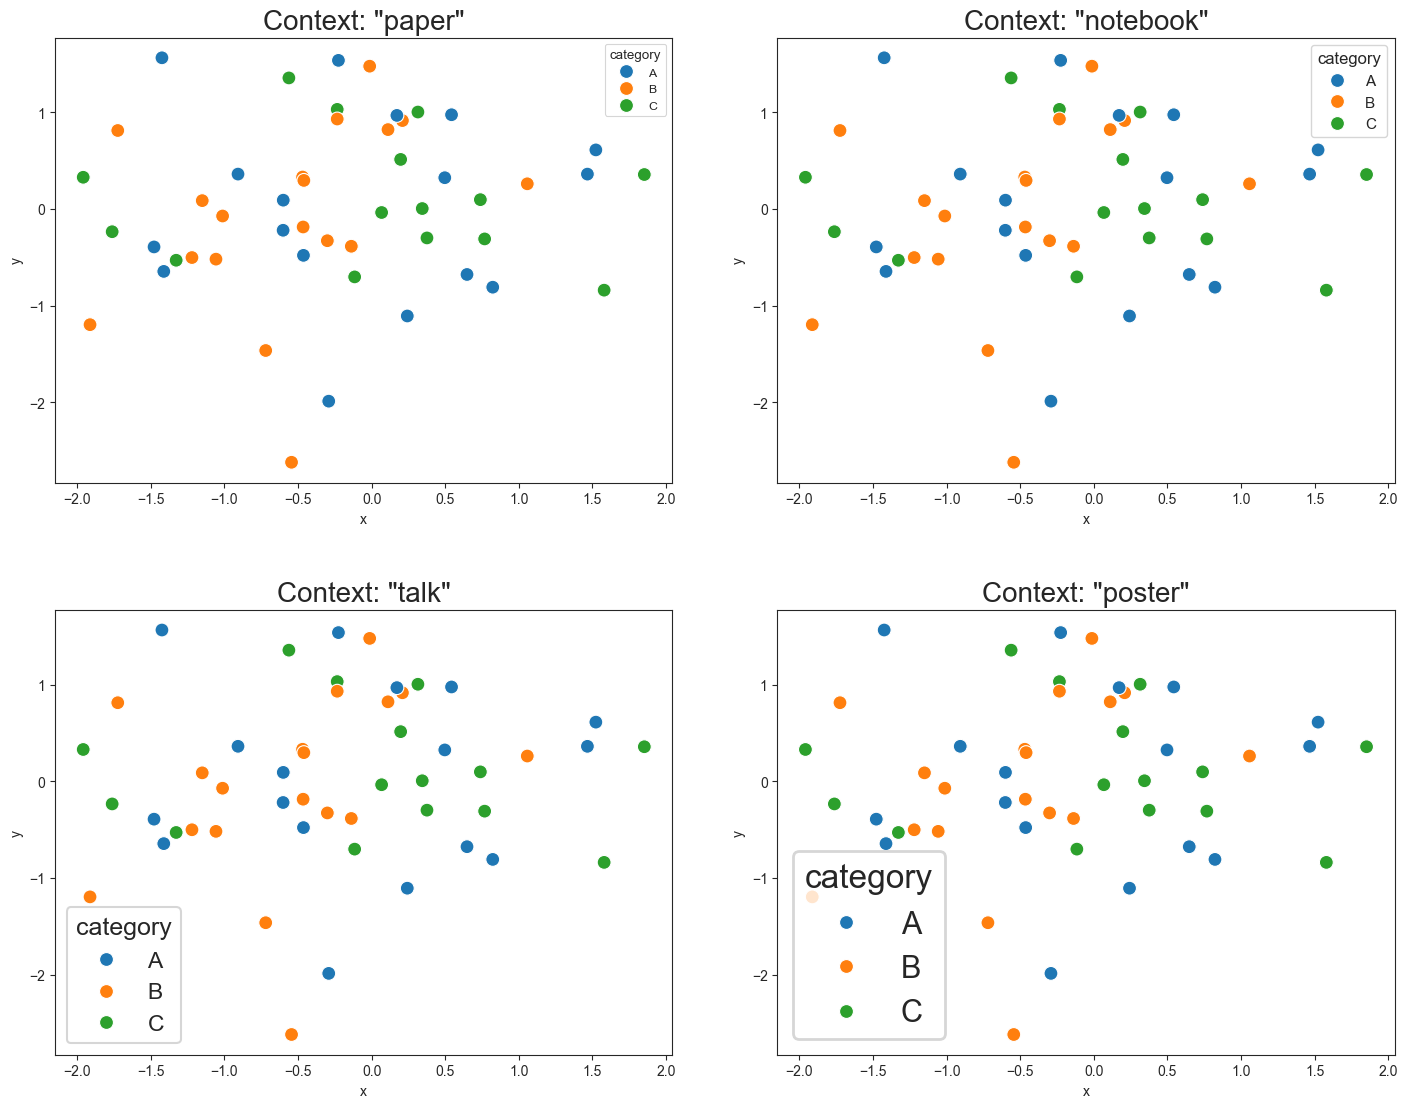

In [3]:
np.random.seed(42)
data = pd.DataFrame({
    'x': np.random.randn(50),
    'y': np.random.randn(50),
    'category': np.random.choice(['A', 'B', 'C'], 50)
})

contexts = ['paper', 'notebook', 'talk', 'poster']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, context in enumerate(contexts):
    with sns.plotting_context(context): # type: ignore
        ax = axes[i]
        sns.scatterplot(data=data, x='x', y='y', hue='category', s=100, ax=ax)
        ax.set_title(f'Context: "{context}"', fontsize=20)

plt.tight_layout(pad=4.0)
plt.show()

上面的代码中：
- `with sns.plotting_context(context):`：在 `with` 语句块中临时应用指定的上下文样式，确保每个子图使用不同的上下文设置；
- `ax.set_title(f'Context: "{context}"', fontsize=20)`：图表标题原本也受上下文影响，但这里将标题字体大小固定为 `20` 会覆盖上下文中的字体大小设定，以便更清晰地展示不同上下文对图表其他元素的影响；
- `plt.tight_layout(pad=4.0)`：增加子图的内边距，防止标题重叠。

#### 调色板

`seaborn` 提供了丰富的调色板选项：通过修改绘图函数的 `palette` 参数，可以改变图表的配色。

下面的代码展示了如何使用内置的不同调色板：

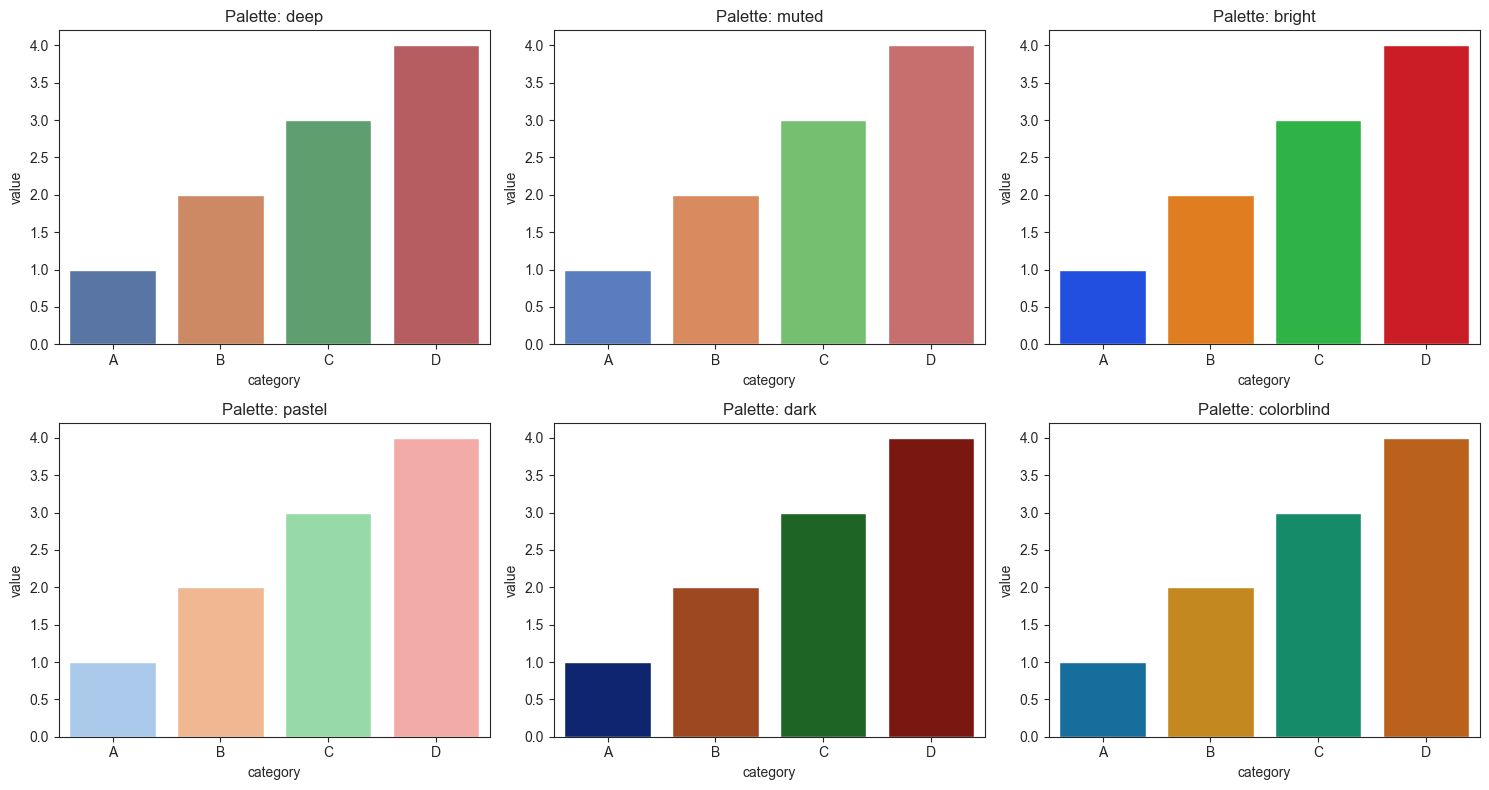

In [4]:
x_data = ['A', 'B', 'C', 'D']
y_data = [1, 2, 3, 4]
df = pd.DataFrame({'category': x_data, 'value': y_data})

palettes = ['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, palette in enumerate(palettes):
    ax = axes[i]
    sns.barplot(data=df, x='category', y='value', palette=palette, ax=ax)
    ax.set_title(f'Palette: {palette}')

plt.tight_layout()
plt.show()

## 绘图方法

### 分布图

分布图是用于展示数据分布情况的图表类型，`seaborn` 提供了多种分布图绘制方法，常用的有以下几种：
- 直方图（*Histogram*）：使用 `sns.histplot()` 函数绘制，适用于展示单变量数据的频率分布；
- 核密度估计图（*KDE Plot*）：使用 `sns.kdeplot()` 函数绘制，适用于展示数据的概率密度分布；
- 地毯图（*Rug Plot*）：使用 `sns.rugplot()` 函数绘制，适用于展示数据点在轴上的分布情况；
- 分布图（*Dist Plot*）：使用 `sns.displot()` 函数绘制，结合了直方图、核密度估计图和地毯图，适用于综合展示数据的分布特征；
- ECDF 图（*Empirical Cumulative Distribution Function Plot*）：使用 `sns.ecdfplot()` 函数绘制，适用于展示数据的累积分布情况。

为了下面的代码展示方便，先用随机函数生成一些示例数据：

In [5]:
np.random.seed(42)
data = np.random.normal(0, 1, 1000)
df = pd.DataFrame({'value': data})

`sns.histplot(data, x, y, hue, bins, kde, stat, element)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `bins`：直方图的箱数
- `kde`：是否叠加核密度估计曲线
- `stat`：统计量，可为 `'count'`, `'frequency'`, `'density'`

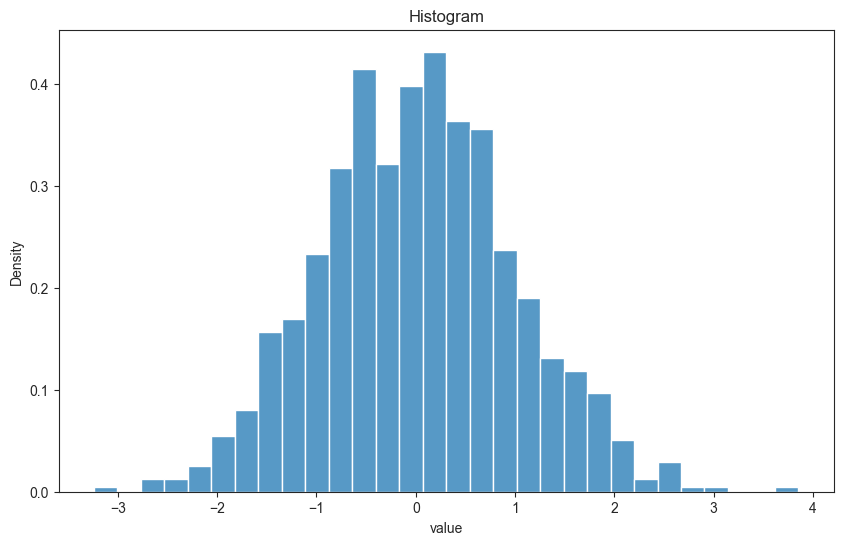

In [6]:
plt.figure(figsize=(10, 6))
df.replace([np.inf, -np.inf], np.nan, inplace=True)
sns.histplot(data=df, x='value', bins=30, stat='density')
plt.title('Histogram')
plt.show()

`kdeplot(data, x, y, hue, fill, bw_adjust, cut, common_norm)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `fill`：是否填充曲线下方区域
- `bw_adjust`：带宽调整参数，控制平滑程度
- `cut`：控制曲线延伸范围的参数
- `common_norm`：是否对所有组进行归一化

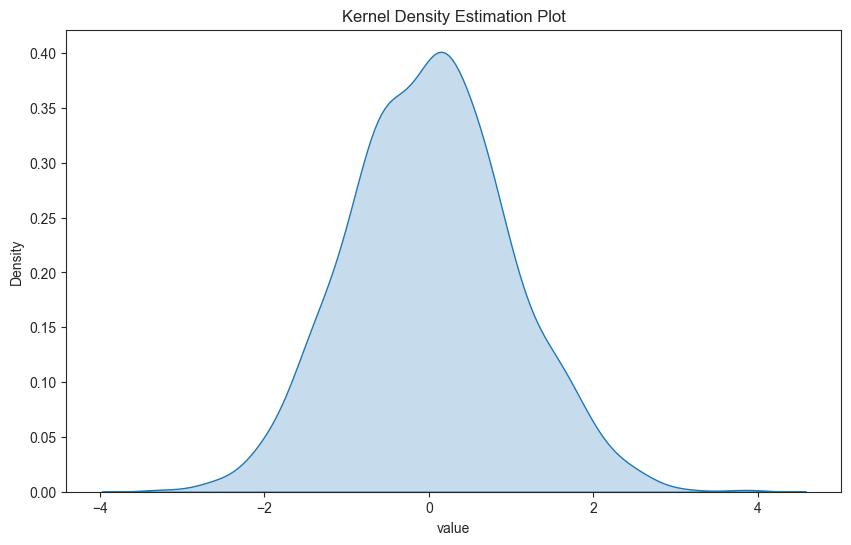

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='value', fill=True)
plt.title('Kernel Density Estimation Plot')
plt.show()

`sns.rugplot(data, x, y, hue, height, axis)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `height`：地毯线的高度
- `axis`：绘制轴，可为 `'x'`，`'y'`

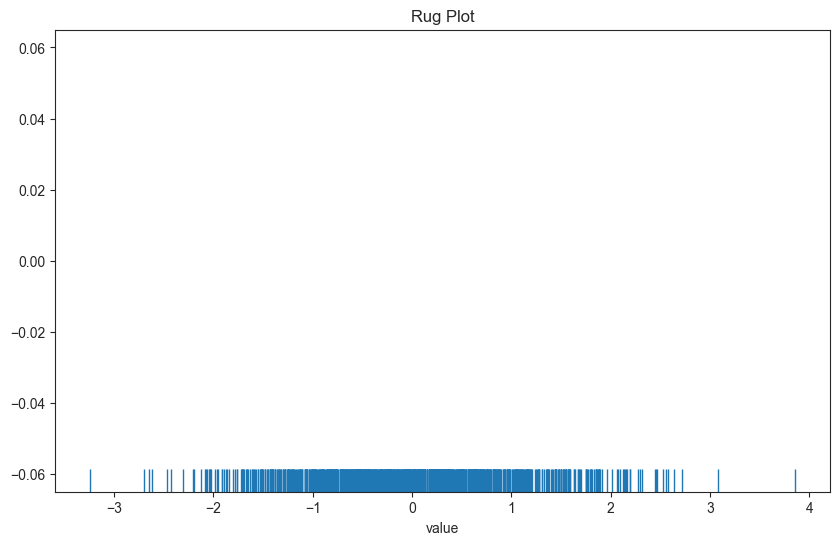

In [8]:
plt.figure(figsize=(10, 6))
sns.rugplot(data=df, x='value', height=0.05)
plt.title('Rug Plot')
plt.show()

`sns.displot(data, x, y, hue, kind, bins, kde, rug)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `kind`：图表类型，可为 `'hist'`, `'kde'`, `'ecdf'`
- `kde`：是否显示核密度估计曲线
- `rug`：是否显示地毯图

<Figure size 1000x600 with 0 Axes>

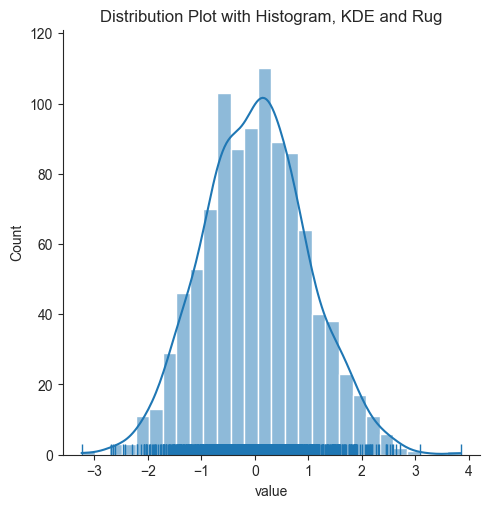

In [9]:
plt.figure(figsize=(10, 6))
sns.displot(data=df, x='value', kind='hist', kde=True, rug=True)
plt.title('Distribution Plot with Histogram, KDE and Rug')
plt.show()

`sns.ecdfplot(data, x, y, hue, stat, complementary)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `stat`：统计量，可为 `'count'`, `'proportion'`, `'percent'`
- `complementary`：是否绘制互补累积分布

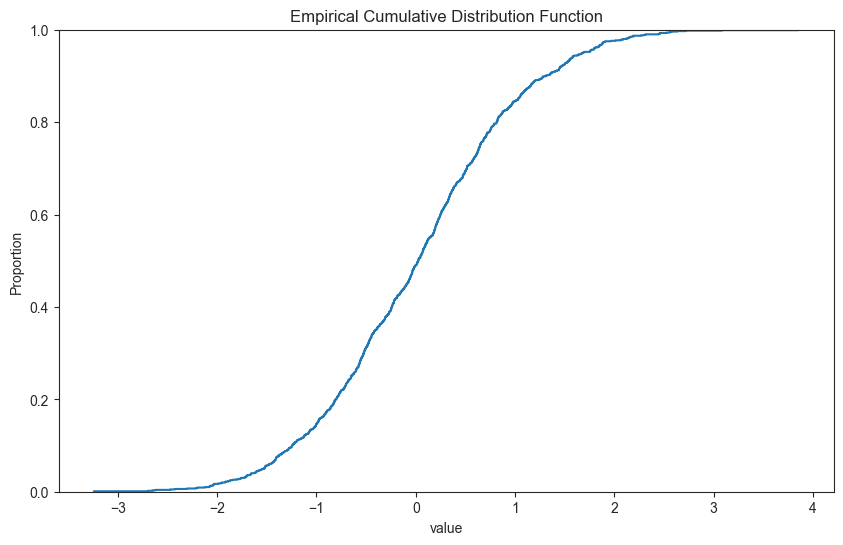

In [10]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x='value')
plt.title('Empirical Cumulative Distribution Function')
plt.show()

### 关系图

关系图用于展示两个或多个变量之间的关系，`seaborn` 提供了多种关系图绘制方法，常用的有以下几种：
- 关系散点图（*Relational Scatter Plot*）：使用 `sns.relplot()` 函数绘制，支持用点或线展示，并支持分面展示；
- 散点图（*Scatter Plot*）：使用 `sns.scatterplot()` 函数绘制；
- 线图（*Line Plot*）：使用 `sns.lineplot()` 函数绘制。

先生成一些示例数据：

In [11]:
np.random.seed(42)
rel_data = pd.DataFrame({
    'x': np.linspace(0, 10, 100),
    'y': 2 * np.linspace(0, 10, 100) + np.random.normal(0, 2, 100),
    'category': np.random.choice(['A', 'B', 'C'], 100)
})

`sns.relplot(data, x, y, hue, size, style, kind, col, row)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `size`：点的大小变量名
- `style`：点的样式变量名
- `kind`：图表类型，可为 `'scatter'`, `'line'`
- `col`：列分面变量名
- `row`：行分面变量名

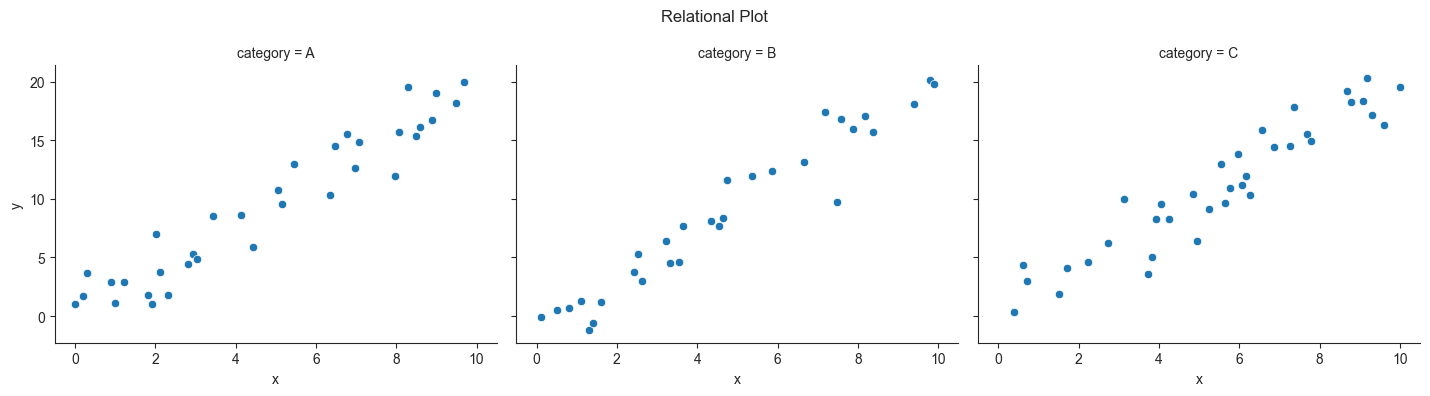

In [12]:
sns.relplot(data=rel_data, x='x', y='y', kind='scatter', 
            col='category', height=4, aspect=1.2)
plt.suptitle('Relational Plot')
plt.tight_layout()
plt.show()

`sns.scatterplot(data, x, y, hue, size, style, palette, sizes)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：颜色分组变量名
- `size`：大小分组变量名
- `style`：点的样式变量名
- `palette`：调色板
- `sizes`：大小范围列表

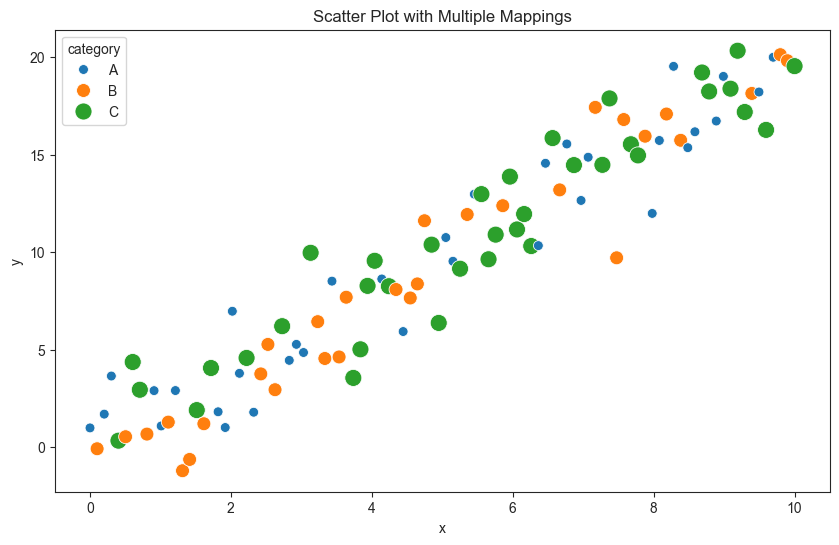

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rel_data, x='x', y='y', hue='category', 
                size='category', sizes=[50, 100, 150])
plt.title('Scatter Plot with Multiple Mappings')
plt.show()

`sns.lineplot(data, x, y, hue, size, style, palette, dashes)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：颜色分组变量名
- `size`：大小分组变量名
- `style`：线型分组变量名
- `palette`：调色板
- `dashes`：是否使用虚线

线图经常用于展示时间序列数据的变化趋势，例如股票价格、气温变化等，所以我们构造一些时序数据：

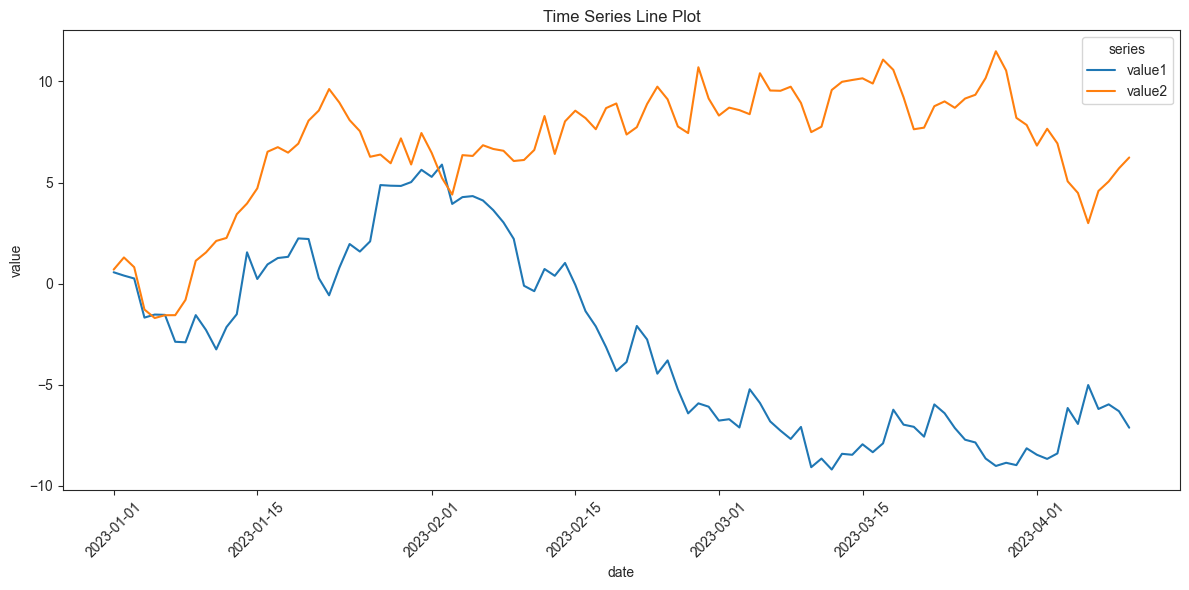

In [14]:
dates = pd.date_range('2023-01-01', periods=100, freq='D')
time_data = pd.DataFrame({
    'date': dates,
    'value1': np.cumsum(np.random.randn(100)),
    'value2': np.cumsum(np.random.randn(100))
})
plt.figure(figsize=(12, 6))
sns.lineplot(data=time_data.melt(id_vars='date', var_name='series', 
                                value_name='value'),
             x='date', y='value', hue='series')
plt.title('Time Series Line Plot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 分类图

分类图用于展示分类变量与数值变量之间的关系，`seaborn` 提供了多种分类图绘制方法，常用的有以下几种：
- 分类图（*Categorical Plot*）：使用 `sns.catplot()` 函数绘制，支持多种图表类型，并支持分面展示；
- 条形散点图（*Strip Plot*）：使用 `sns.stripplot()` 函数绘制；
- 蜂群图（*Swarm Plot*）：使用 `sns.swarmplot()` 函数绘制；
- 箱线图（*Box Plot*）：使用 `sns.boxplot()` 函数绘制；
- 小提琴图（*Violin Plot*）：使用 `sns.violinplot()` 函数绘制；
- 增强箱线图（*Enhanced Boxen Plot*）：使用 `sns.boxenplot()` 函数绘制；
- 点图（*Point Plot*）：使用 `sns.pointplot()` 函数绘制；
- 条形图（*Bar Plot*）：使用 `sns.barplot()` 函数绘制；
- 计数图（*Count Plot*）：使用 `sns.countplot()` 函数绘制。

下面先生成一些示例数据：

In [15]:
np.random.seed(42)
cat_data = pd.DataFrame({
    'category': np.random.choice(['A', 'B', 'C', 'D'], 200),
    'value': np.random.normal(0, 1, 200),
    'group': np.random.choice(['X', 'Y'], 200)
})

`sns.catplot(data, x, y, hue, kind, col, row, order)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `kind`：图表类型，可为 `'strip'`, `'swarm'`, `'box'`, `'violin'`
- `col`：列分面变量名
- `row`：行分面变量名
- `order`：分类变量的顺序

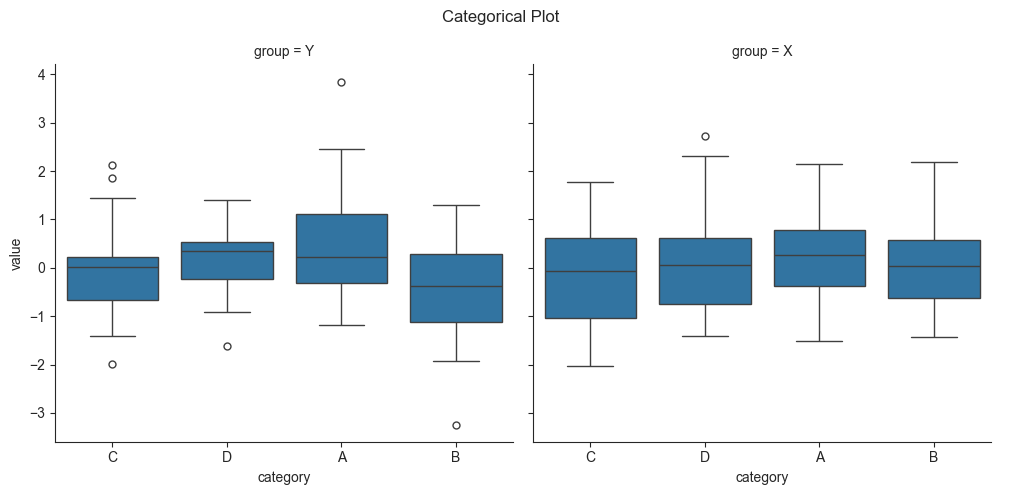

In [16]:
sns.catplot(data=cat_data, x='category', y='value', 
            kind='box', col='group', height=5, aspect=1)
plt.suptitle('Categorical Plot')
plt.tight_layout()
plt.show()

`sns.stripplot(data, x, y, hue, order, jitter, dodge)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `jitter`：抖动程度
- `dodge`：是否分组显示
- `alpha`：透明度

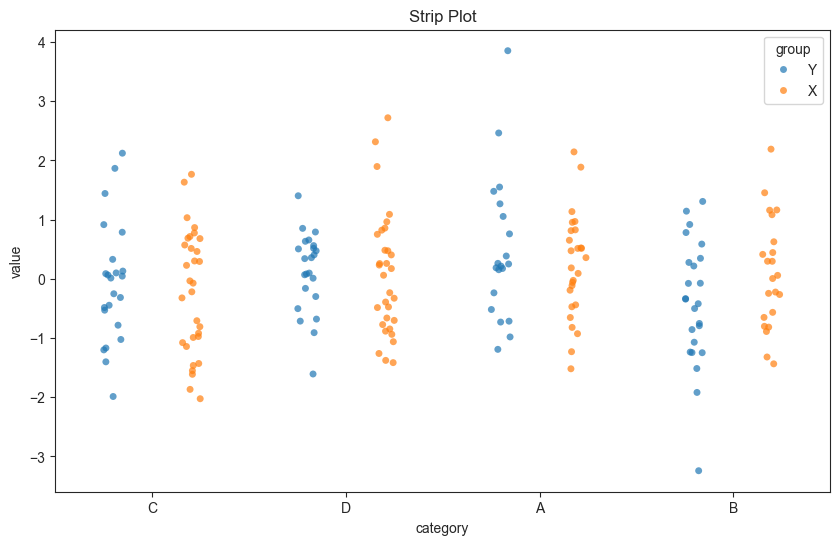

In [17]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=cat_data, x='category', y='value', 
              hue='group', dodge=True, alpha=0.7)
plt.title('Strip Plot')
plt.show()

`sns.swarmplot(data, x, y, hue, order, dodge)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `dodge`：是否分组显示

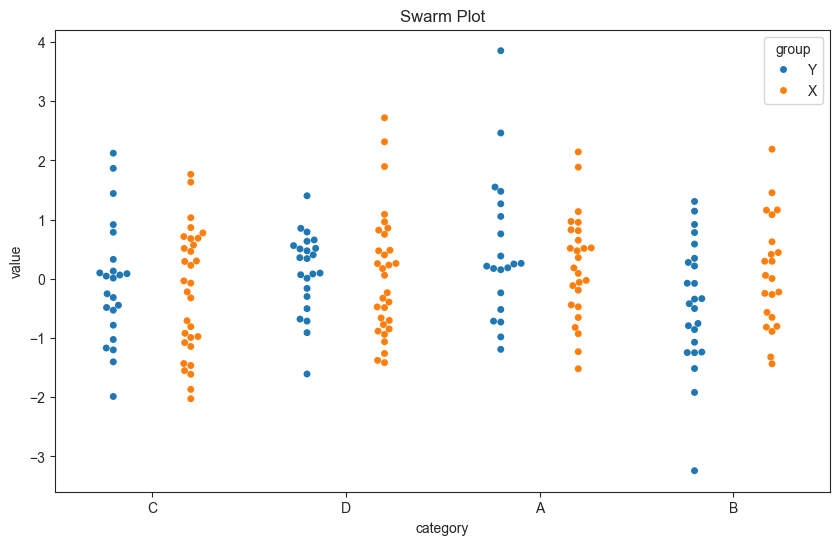

In [18]:
plt.figure(figsize=(10, 6))
sns.swarmplot(data=cat_data, x='category', y='value', 
              hue='group', dodge=True)
plt.title('Swarm Plot')
plt.show()

`sns.boxplot(data, x, y, hue, order, orient, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平）
- `width`：箱体宽度

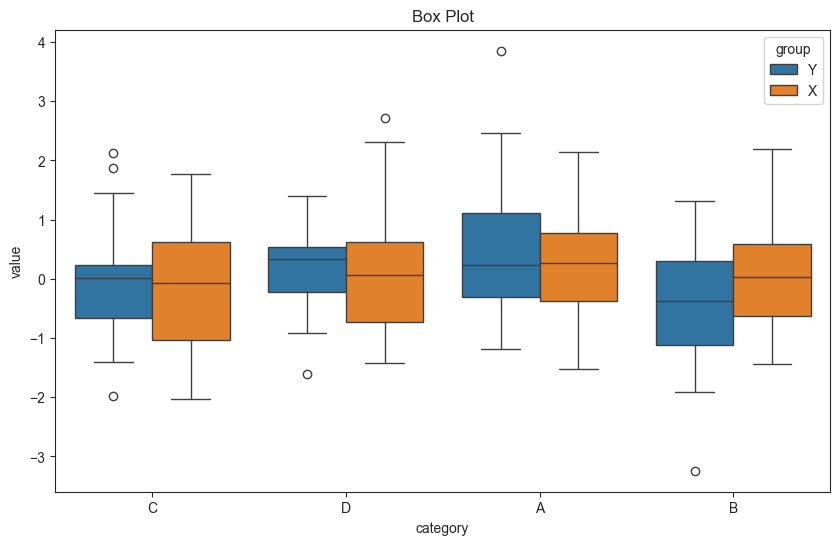

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=cat_data, x='category', y='value', hue='group')
plt.title('Box Plot')
plt.show()

`sns.violinplot(data, x, y, hue, order, split, scale, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `split`：是否分割小提琴
- `scale`：缩放方式，可为 `'area', 'count', 'width'`
- `width`：小提琴宽度

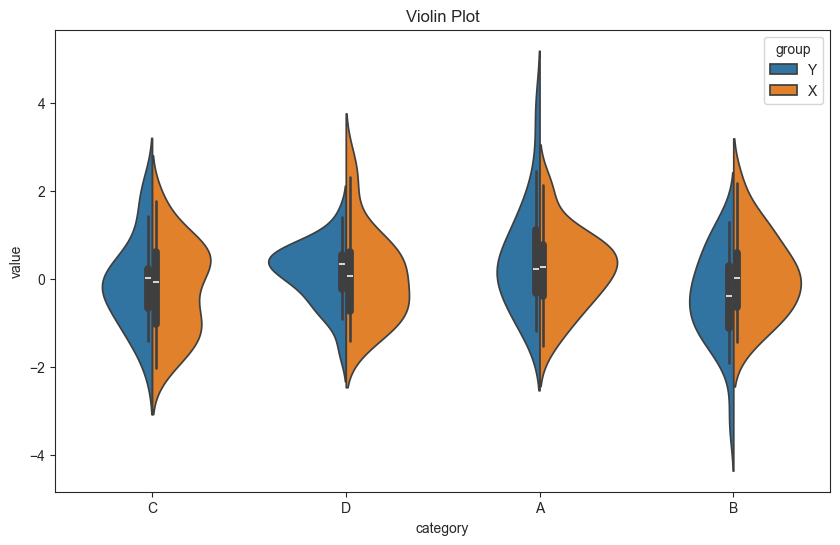

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=cat_data, x='category', y='value', 
               hue='group', split=True)
plt.title('Violin Plot')
plt.show()

`sns.boxenplot(data, x, y, hue, order, orient, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：方向，可为 `'v', 'h'`
- `width`：箱体宽度

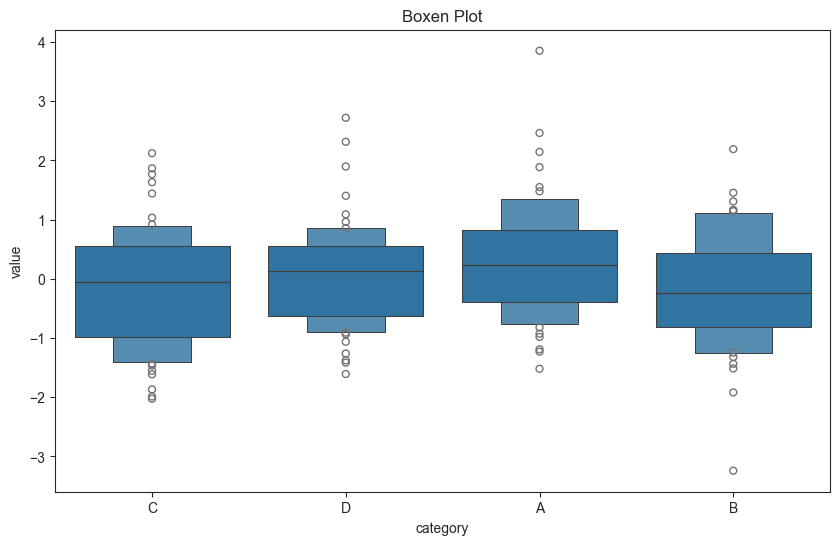

In [21]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=cat_data, x='category', y='value')
plt.title('Boxen Plot')
plt.show()

`sns.pointplot(data, x, y, hue, order, ci, capsize, join)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `ci`：置信区间大小
- `capsize`：误差条帽大小
- `join`：是否连接点

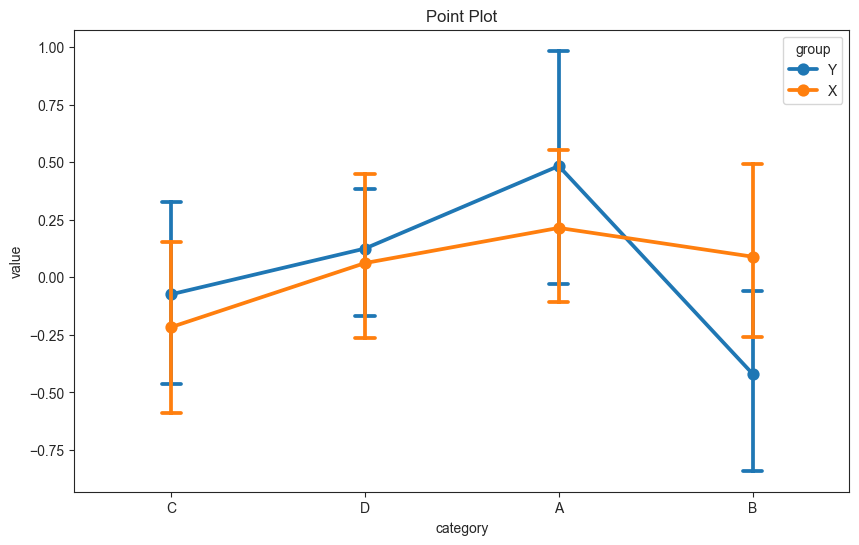

In [22]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=cat_data, x='category', y='value', 
              hue='group', ci=95, capsize=0.1)
plt.title('Point Plot')
plt.show()

`sns.barplot(data, x, y, hue, order, orient, ci, estimator)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平）
- `ci`：置信区间大小
- `estimator`：统计函数，可为 `'mean', 'median', 'sum'`

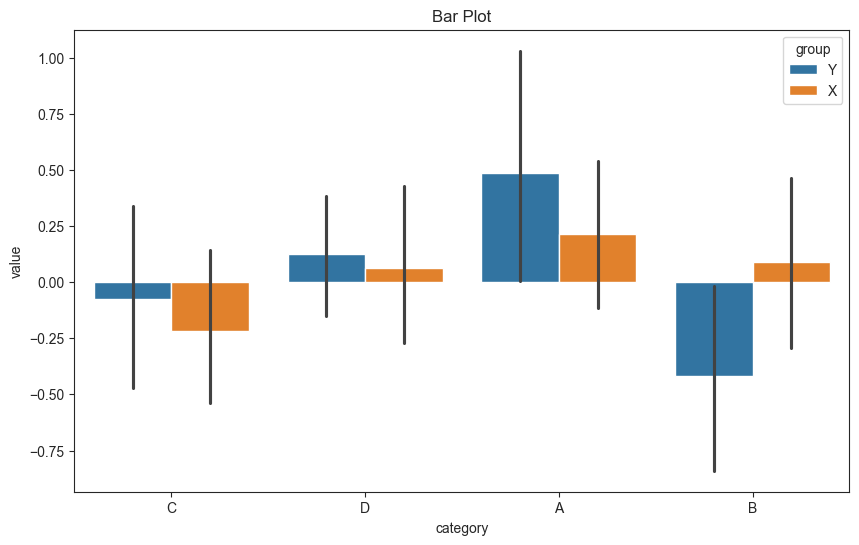

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cat_data, x='category', y='value', 
            hue='group', ci=95)
plt.title('Bar Plot')
plt.show()

`sns.countplot(data, x, y, hue, order, orient)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平`)

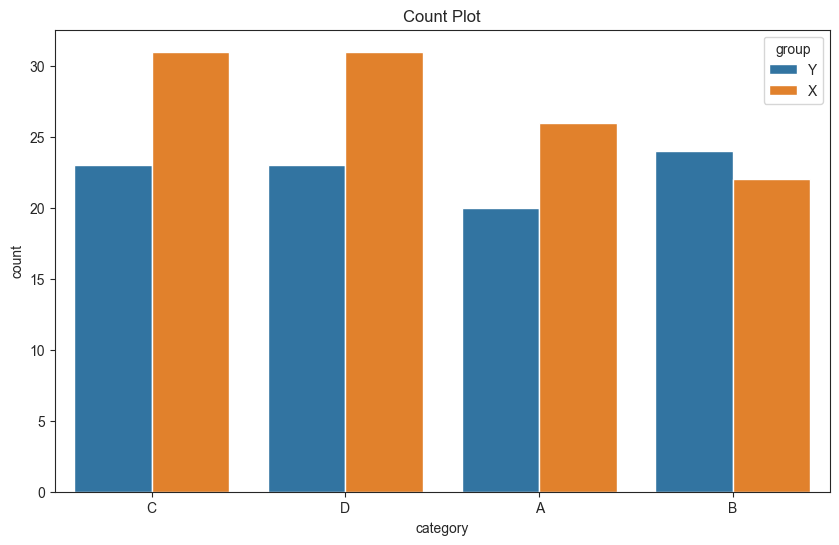

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=cat_data, x='category', hue='group')
plt.title('Count Plot')
plt.show()

### 回归图

回归图用于展示变量之间的回归关系，`seaborn` 提供了多种回归图绘制方法，常用的有以下几种：
- 回归图（*Regression Plot*）：使用 `sns.regplot()` 函数绘制，适用于展示单变量回归关系；
- 线性模型图（*Linear Model Plot*）：使用 `sns.lmplot()` 函数绘制，适用于展示多变量回归关系，并支持分面展示；
- 残差图（*Residual Plot*）：使用 `sns.residplot()` 函数绘制，适用于展示回归模型的残差分布情况。

先生成一些示例数据：

In [25]:
np.random.seed(42)
x_reg = np.linspace(0, 10, 50)
y_reg = 2 * x_reg + 1 + np.random.normal(0, 2, 50)
reg_data = pd.DataFrame({'x': x_reg, 'y': y_reg})

`sns.regplot(data, x, y, hue, scatter, fit_reg, ci)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `scatter`：是否绘制散点图
- `scatter_kws`：散点图样式参数
- `line_kws`：回归线样式参数
- `fit_reg`：是否拟合回归线
- `ci`：置信区间大小

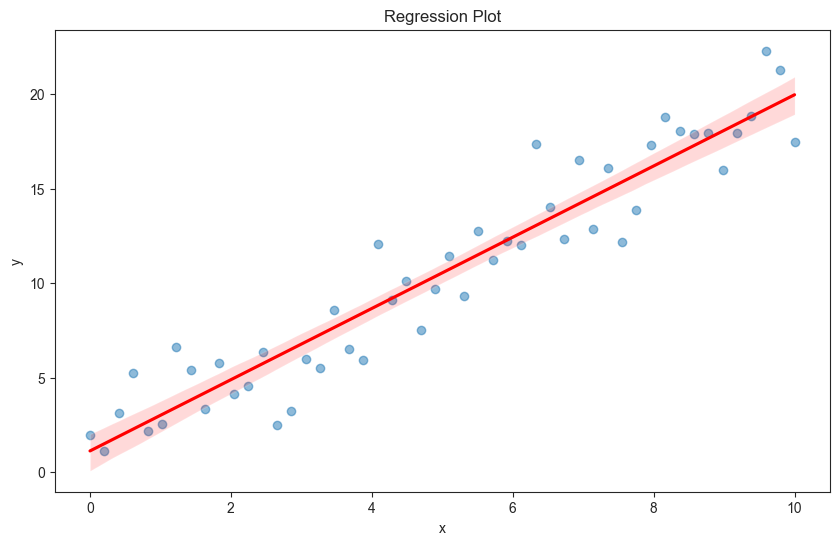

In [26]:
plt.figure(figsize=(10, 6))
sns.regplot(data=reg_data, x='x', y='y', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Regression Plot')
plt.show()

`sns.lmplot(data, x, y, hue, col, row, order, logistic)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `col`：列分面变量名
- `row`：行分面变量名
- `order`：回归多项式阶数
- `logistic`：是否进行逻辑回归

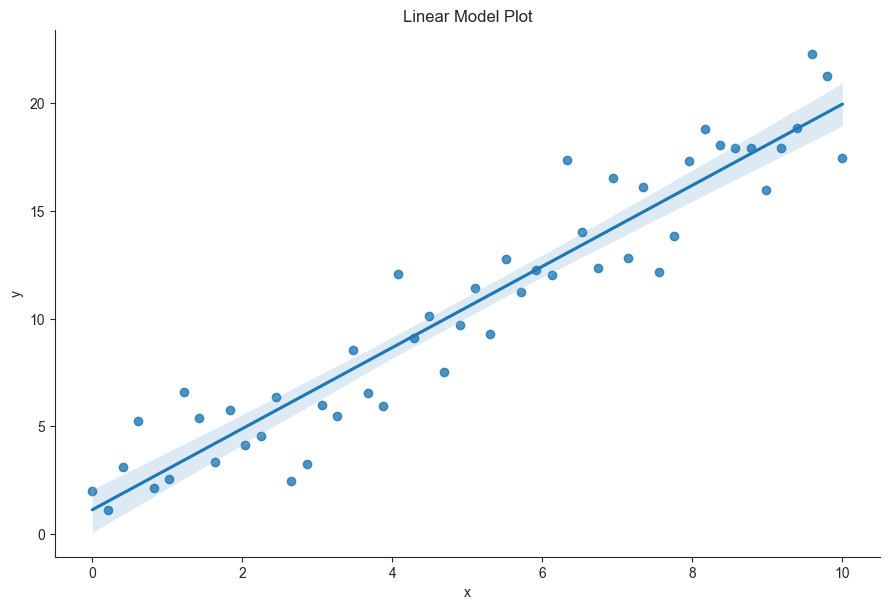

In [27]:
sns.lmplot(data=reg_data, x='x', y='y', 
           height=6, aspect=1.5)
plt.title('Linear Model Plot')
plt.show()

`sns.residplot(data, x, y, lowess, scatter)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `lowess`：是否使用局部加权回归
- `scatter`：是否显示散点

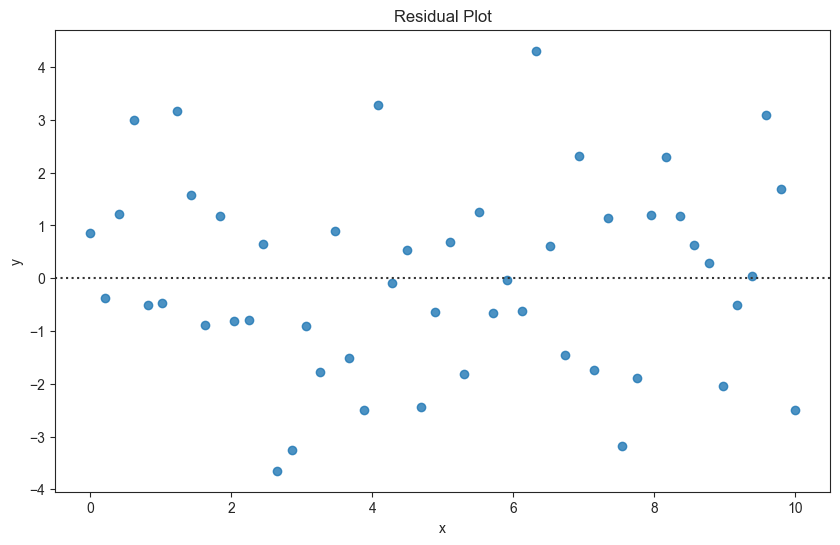

In [28]:
plt.figure(figsize=(10, 6))
sns.residplot(data=reg_data, x='x', y='y')
plt.title('Residual Plot')
plt.show()

### 矩阵图

矩阵图用于展示变量之间的相关性或分布情况，`seaborn` 提供了多种矩阵图绘制方法，常用的有以下几种：
- 热力图（*Heatmap*）：使用 `sns.heatmap()` 函数绘制，适用于展示矩阵数据的热度分布；
- 聚类热力图（*Clustered Heatmap*）：使用 `sns.clustermap()` 函数绘制，适用于展示带有聚类信息的热力图。

先生成一些示例数据：

In [29]:
np.random.seed(42)
matrix_data = np.random.randn(10, 10)
corr_matrix = np.corrcoef(matrix_data)

`sns.heatmap(data, annot, fmt, cmap, center, square)`
- `data`：二维数据矩阵
- `annot`：是否显示数值标注
- `fmt`：数值格式字符串
- `cmap`：调色板名称
- `center`：颜色映射中心值
- `square`：是否保持正方形

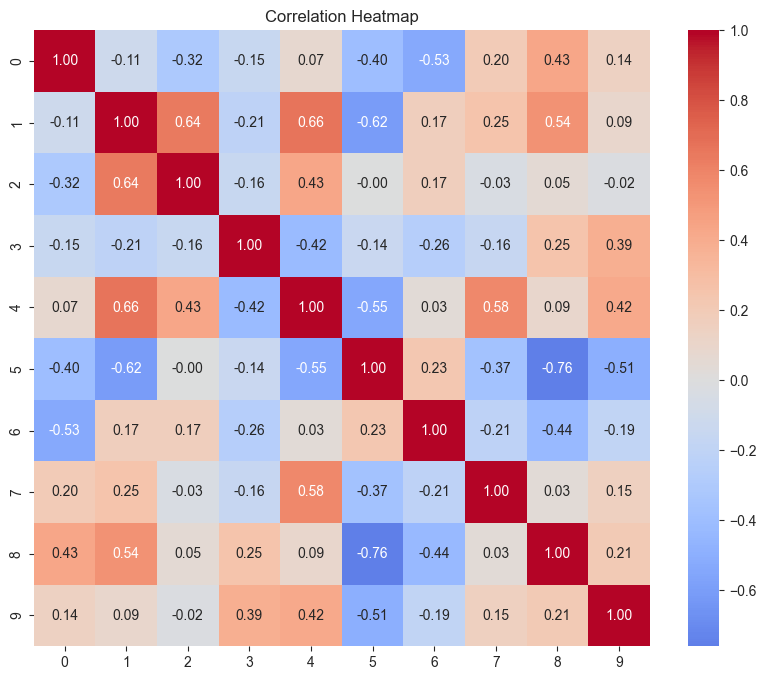

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.show()

`sns.clustermap(data, method, metric, cmap, standard_scale)`
- `data`：二维数据矩阵
- `method`：聚类方法，可为 `'single'`, `'complete'`, `'average'`, `'ward'`
- `metric`：距离度量，可为 `'euclidean'`, `'cityblock'`
- `cmap`：调色板名称
- `standard_scale`：标准化方式，可为 `0`, `1`

<Figure size 1000x800 with 0 Axes>

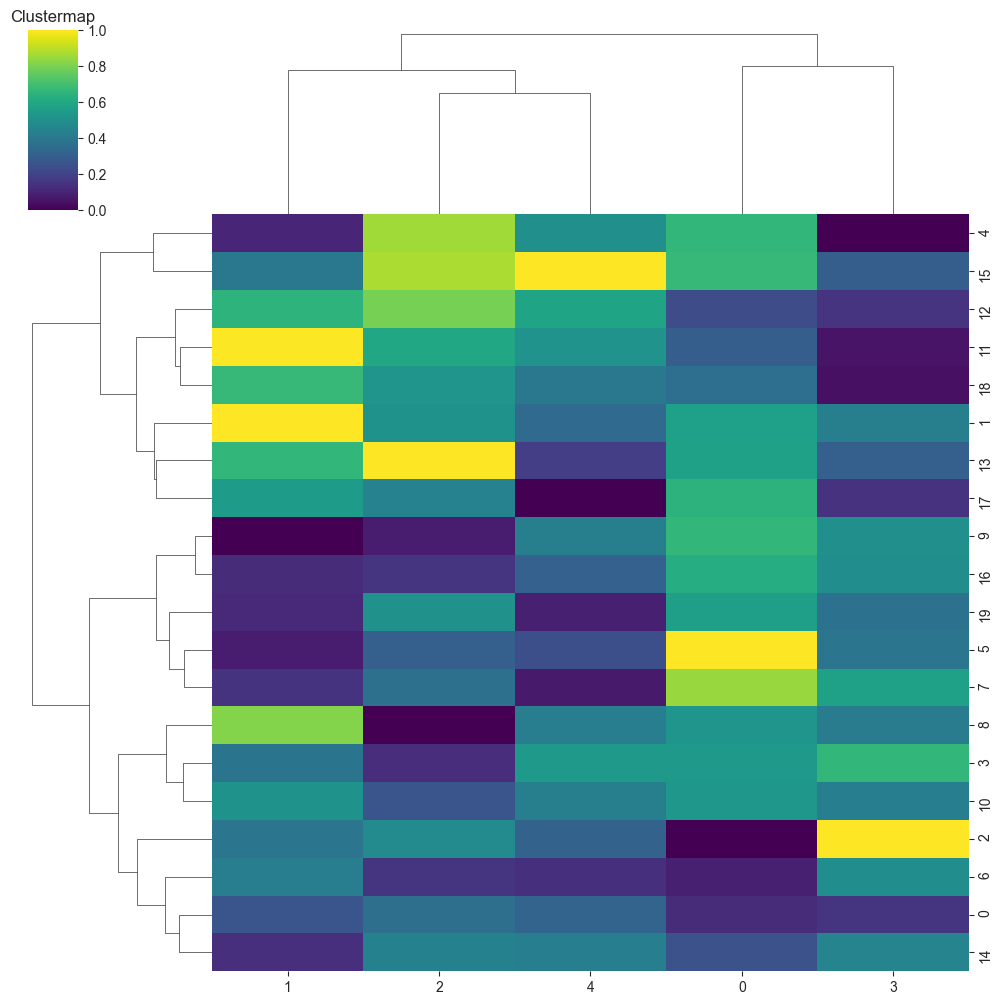

In [31]:
from scipy.cluster.hierarchy import linkage
# 生成随机数据
cluster_data = np.random.randn(20, 5)
plt.figure(figsize=(10, 8))
sns.clustermap(cluster_data, method='ward', cmap='viridis',
               standard_scale=1)
plt.title('Clustermap')
plt.show()

## 小结：常用方法一览

| 函数名 | 功能说明 | 作用 |
| :--- | :--- | :--- |
| **样式设置** | | |
| `set_style()` | 设置绘图样式 | 控制图表的整体美学风格，如背景色和网格线，使图表更美观或符合特定规范。 |
| `set_palette()` | 设置调色板 | 定义图表中使用的颜色方案，以增强可读性、区分不同类别或符合特定主题。 |
| `set_context()` | 设置绘图上下文 | 根据输出场景（如论文、演讲、海报）调整图表元素（字体、线宽）的大小，确保清晰度。 |
| **分布图** | | |
| `histplot()` | 绘制直方图 | 观察单个数值变量的频率分布，了解数据的集中趋势、离散程度和基本形态。 |
| `kdeplot()` | 绘制核密度估计图 | 通过平滑曲线展示数据的概率密度，用于估计其真实的、连续的分布形状。 |
| `rugplot()` | 绘制地毯图 | 在坐标轴上标记每个数据点的精确位置，常与KDE或直方图结合使用以显示原始数据分布。 |
| `displot()` | 绘制分布图（图形级） | 作为绘制分布图的统一入口，可灵活组合多种分布图并支持分面，便于全面探索数据分布。 |
| `ecdfplot()` | 绘制经验累积分布函数图 | 显示数据点的累积分布，直观地看出小于某个值的样本比例，便于比较不同分布。 |
| **关系图** | | |
| `relplot()` | 绘制关系图（图形级） | 作为绘制关系图的统一入口，可轻松创建散点图或线图，并支持按类别分面，进行多维度比较。 |
| `scatterplot()` | 绘制散点图 | 可视化两个数值变量之间的关系模式，如相关性、聚类和离群点。 |
| `lineplot()` | 绘制线图 | 特别适合展示数据随连续变量（如时间）变化的趋势，并能显示置信区间以表示不确定性。 |
| **分类图** | | |
| `catplot()` | 绘制分类图（图形级） | 作为绘制分类图的统一入口，可创建多种类型的分类图并支持分面，便于比较不同类别的数据。 |
| `stripplot()` | 绘制抖动散点图 | 以抖动方式展示每个类别的原始数据点，避免重叠，适合小数据集的分布观察。 |
| `swarmplot()` | 绘制蜂群图 | 通过算法调整数据点位置，使其完全不重叠，能清晰展示数据分布，但不适合大数据集。 |
| `boxplot()` | 绘制箱线图 | 通过五数概括法（最小值、下四分位数、中位数、上四分位数、最大值）和异常值来总结数据分布。 |
| `violinplot()` | 绘制小提琴图 | 结合箱线图和KDE图的特点，同时展示数据的分布摘要和概率密度形状，信息更丰富。 |
| `boxenplot()` | 绘制增强箱线图 | 提供比箱线图更详细的分布信息（多个分位数），特别适合大数据集的分布探索。 |
| `pointplot()` | 绘制点图 | 用点表示集中趋势，用线表示置信区间，便于精确比较不同类别间的差异，尤其关注变化趋势。 |
| `barplot()` | 绘制条形图 | 用条形的高度表示集中趋势（如均值），常用于比较不同类别的数值大小。 |
| `countplot()` | 绘制计数图 | 专门用于统计并可视化每个分类类别中出现的样本数量，相当于分类数据的直方图。 |
| **回归图** | | |
| `regplot()` | 绘制回归图 | 将散点图与线性回归模型拟合结果结合，直观展示两个变量间的线性关系及其强度。 |
| `lmplot()` | 绘制线性模型图（图形级） | 功能与`regplot`类似，但作为图形级函数，增加了按类别分面的能力，便于分组分析回归关系。 |
| `residplot()` | 绘制残差图 | 用于回归诊断，通过可视化残差（预测值与真实值之差）来检验模型的假设是否成立。 |
| **矩阵图** | | |
| `heatmap()` | 绘制热力图 | 用颜色深浅表示矩阵中数值的大小，非常适合可视化相关性矩阵、混淆矩阵等二维数据。 |
| `clustermap()` | 绘制聚类图 | 在热力图的基础上对行列进行层次聚类，并将相似的项聚集在一起，便于发现数据中的模式或群组。 |

如果希望了解更多详细信息和高级用法，可以参考 `seaborn` 的[官方文档](https://seaborn.pydata.org/)。

## 多变量可视化

**什么是多变量图？**

多变量图是一种在单一图表中同时展示和探索三个或更多变量之间关系的可视化方法。

它的核心思想是：不再孤立地看待每个变量，而是通过视觉（如颜色、大小、形状、透明度或分面）将多个变量的信息融合在一起，从而揭示它们之间复杂的相互作用、依赖关系和隐藏模式。

可以把它看作是单变量图（如直方图）和双变量图（如散点图）的延伸和升级。

**多变量图的好处**

- 揭示隐藏关系：可以直观地看到不同类别在两个数值维度上的分布差异。
- 提高比较效率：将所有组的数据放在同一坐标系下，可以非常方便地进行直接比较。我们无需为每个类别单独创建图表，就能快速判断哪个类群的密度更高、分布更集中或与其他类群的重叠程度。
- 识别数据结构与异常：有助于识别数据中的聚类、趋势和潜在的异常值。
- 增强信息传达：在报告或演示中，一张好的多变量图比多张单变量图更具说服力，能用更简洁的方式传达更丰富的信息。

### 二维核密度估计图

一维核密度估计图基于一维数据，二维核密度估计图（KDE）则基于二维数据，并用颜色区分变量。

注意，我们只需要传给 `sns.kdeplot()` 两维数据即可，`seaborn` 会自动计算二维核密度估计并绘制等高线图。

<Figure size 1000x600 with 0 Axes>

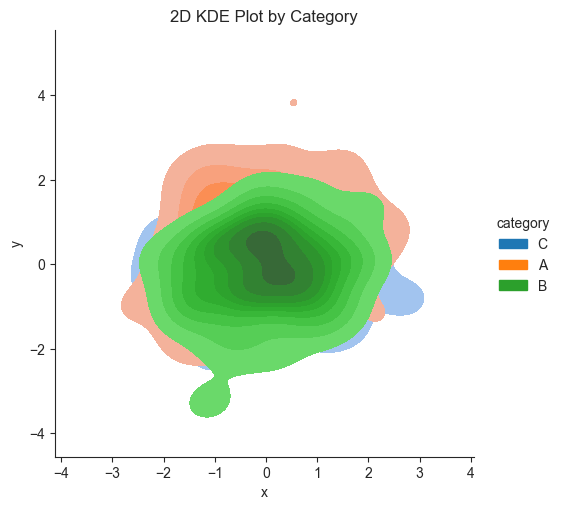

In [32]:
np.random.seed(42)
data_multi = pd.DataFrame({
    'x': np.random.normal(0, 1, 200),
    'y': np.random.normal(0, 1, 200),
    'category': np.random.choice(['A', 'B', 'C'], 200)
})

plt.figure(figsize=(10, 6))
sns.displot(data=data_multi, x='x', y='y', kind='kde', 
            hue='category', fill=True)
plt.title('2D KDE Plot by Category')
plt.show()

### 联合分布图

**什么是联合分布图？**

联合分布图 是一种专门用于同时探索两个数值变量之间关系以及每个变量自身分布的可视化工具。

**好处在哪？**

联合分布图的主要作用是将双变量分析和单变量分析无缝地结合起来，方便我们：
- 同时观察关系与分布
- 快速识别异常值：异常值在中心的散点图中会显得格格不入。
- 比较不同类别的模式
- 理解数据密度

下面的数据是150朵虚拟花的四种尺寸测量值和它们的种类标签：

In [33]:
np.random.seed(42)
iris_data = pd.DataFrame({
    'sepal_length': np.random.normal(5.8, 0.8, 150),
    'sepal_width': np.random.normal(3.0, 0.4, 150),
    'petal_length': np.random.normal(3.8, 1.6, 150),
    'petal_width': np.random.normal(1.2, 0.8, 150),
    'species': np.random.choice(['setosa', 'versicolor', 'virginica'], 150)
})

然后调用 `sns.jointplot()` 创建联合分布图：

<Figure size 1000x600 with 0 Axes>

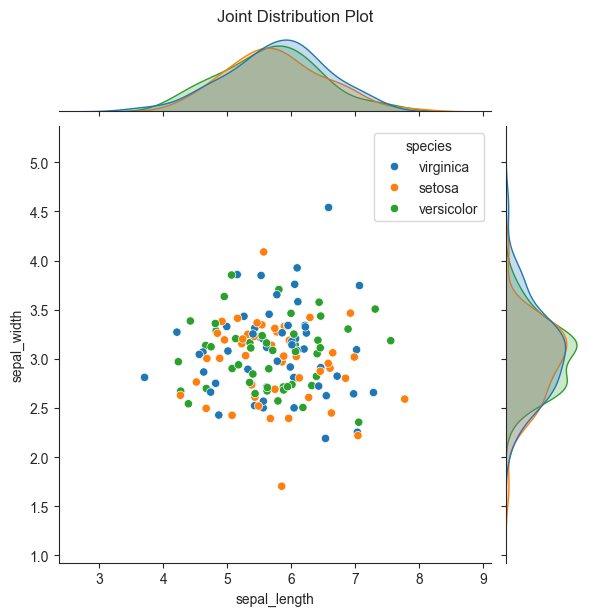

In [34]:
plt.figure(figsize=(10, 6))
sns.jointplot(data=iris_data, x='sepal_length', y='sepal_width',
              hue='species', kind='scatter')
plt.suptitle('Joint Distribution Plot', y=1.02)
plt.show()

### 配对图

**什么是配对图？**

配对图是一个网格状的图表，它能让你在一个视图中快速浏览整个数据集的全貌。

配对图相当于一个数据集的“仪表盘”：

- 对角线上的图：展示每个单个变量的分布情况（直方图或密度图）。
- 非对角线上的图：展示两个变量之间的关系（散点图或回归图）。

**配对图有什么作用？**

通过这一个图，你就能快速掌握整个数据集的全貌，包括变量自身的分布特征和变量之间的相互关系。并且有助于发现数据聚类和可分性。

下面针对前面的花卉数据集，使用 `sns.pairplot()` 创建配对图：

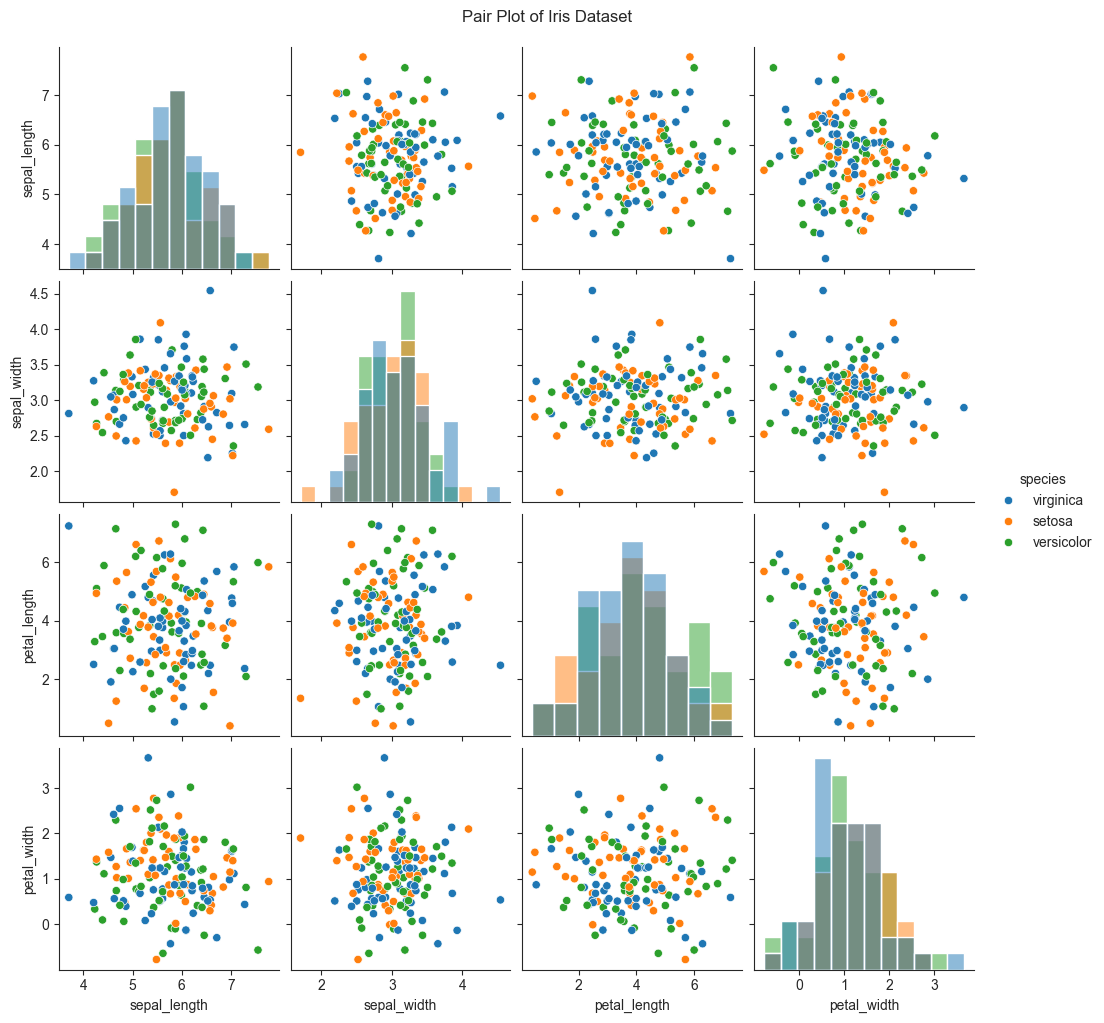

In [35]:
sns.pairplot(data=iris_data, hue='species', diag_kind='hist')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()

### 分面绘图

**什么是分面绘图？**

分面绘图将一个大数据集根据一个或多个分类变量的值，“切片”成多个子集，然后为每个子集绘制一个独立的图表，最后将这些小图表排列成一个网格。

**有什么作用？**

分面绘图是解决“图表过于复杂”问题的利器，其主要作用如下：

- 避免视觉混乱和数据重叠： 分面绘图通过将数据分离开来，从根本上解决了重叠问题，让每个子图都干净、易读。

- 便于进行“同类比较”： 网格化的布局让我们的眼睛可以非常轻松地进行横向和纵向的比较。

- 揭示“条件关系”： 帮助解决“两个变量之间的关系，是否会受到第三个变量的影响？”的问题。

下面的代码展示了 `replplot()` 函数的分面绘图功能：

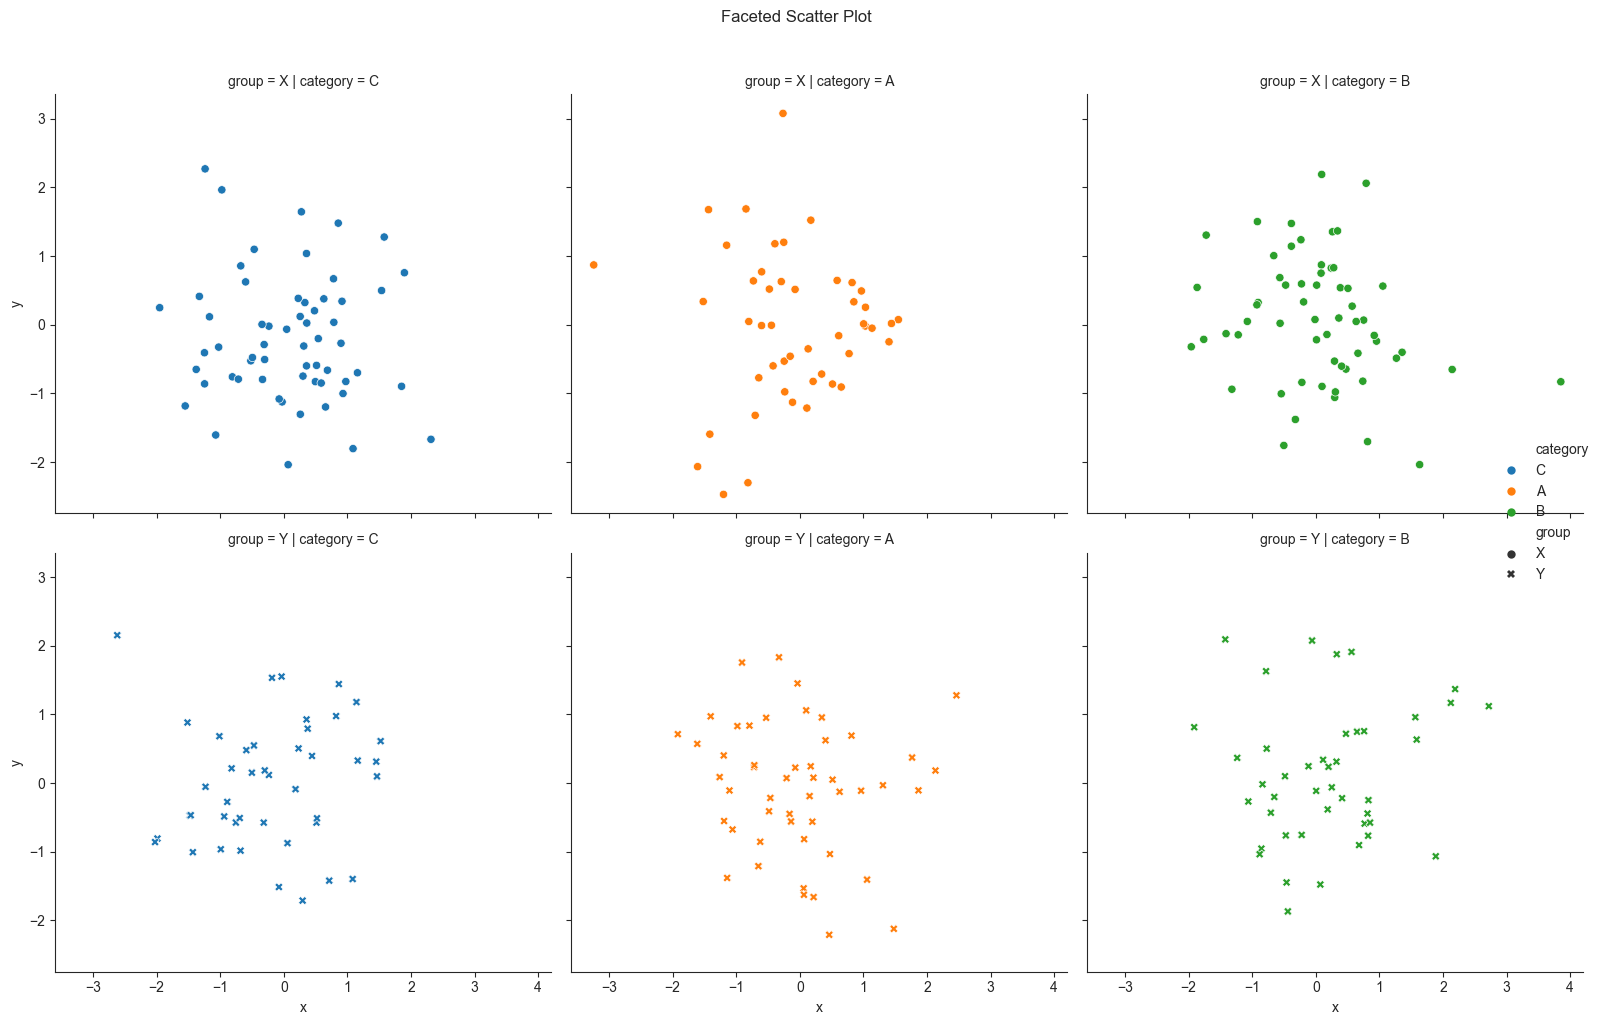

In [36]:
np.random.seed(42)
facet_data = pd.DataFrame({
    'x': np.random.randn(300),
    'y': np.random.randn(300),
    'category': np.random.choice(['A', 'B', 'C'], 300),
    'group': np.random.choice(['X', 'Y'], 300)
})

g = sns.relplot(data=facet_data, x='x', y='y', 
                col='category', row='group', 
                hue='category', style='group')
g.figure.suptitle('Faceted Scatter Plot', y=1.02)
plt.tight_layout()
plt.show()

## 置信区间和误差条

置信区间（*confidence interval*，CI）是一种统计学概念，用于表示估计值的不确定性范围。它通过一个区间来表达我们对某个参数（如均值、比例等）的估计值的置信程度。置信区间通常以百分比表示，如 95% 置信区间表示我们有 95% 的信心认为该区间包含了真实的参数值。

误差条（*error bar*）是一种图形元素，通常用于表示数据点的变异性或不确定性。它们以线段的形式延伸出数据点，显示数据点的可能范围。误差条可以表示标准误差、标准偏差或置信区间等。

`seaborn` 中的许多绘图函数（如 `lineplot()`、`barplot()`、`pointplot()` 等）都支持自动计算和显示置信区间和误差条。通过设置参数 `ci` 和 `capsize`，我们可以控制置信区间的大小和误差条的样式。

- 设置 `ci=95` 即计算出该均值的 95% 置信区间；
- 设置 `capsize=0.1` 为置信区间的误差线添加了“小帽子”，让区间的端点更清晰，视觉效果更好。

下面的代码展示了如何在 `lineplot()` 中使用置信区间和误差条：

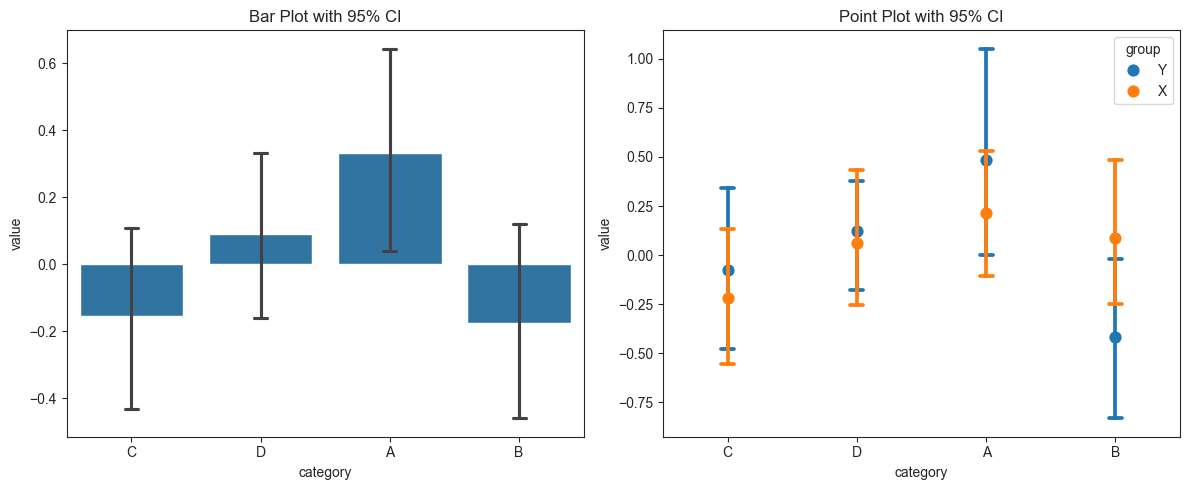

In [37]:
np.random.seed(42)
categories = ['A', 'B', 'C', 'D']
data_cat = pd.DataFrame({
    'category': np.random.choice(categories, 200),
    'value': np.random.normal(0, 1, 200),
    'group': np.random.choice(['X', 'Y'], 200)
})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=data_cat, x='category', y='value', 
            ci=95, capsize=0.1)
plt.title('Bar Plot with 95% CI')

plt.subplot(1, 2, 2)
sns.pointplot(data=data_cat, x='category', y='value', 
              hue='group', ci=95, capsize=0.1, 
              linestyle='none')
plt.title('Point Plot with 95% CI')

plt.tight_layout()
plt.show()